# 📱 SMS Spam Detection — LSTM Classifier

**Dataset :** SMS Spam Collection (ham / spam — 2 classes)  
**Model :** `nn.Embedding → nn.LSTM → nn.Linear` *(no pre-trained models)*  
**Split :** Fixed 80 / 20 train / test  
**Baseline :** 86.6 % (majority-class guess)   |   **Target :** 96 %

---

### Why is this a sequence problem?
Each SMS is a **sequence of word tokens**. The LSTM reads them one step at a time and accumulates hidden state, capturing word-order context that a simple bag-of-words model cannot — e.g. *"you have won a FREE prize"* vs *"you have won the game"* — order and co-occurrence matter critically for spam detection.

## Cell 1 — Imports & Reproducibility

In [14]:
import os, re, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

# ── Reproducibility ───────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on: {DEVICE.upper()}")

Running on: CPU


## Cell 2 — Hyper-parameters

In [15]:
MAXLEN    = 50     # max tokens per SMS (most spam < 50 words)
EMBED_DIM = 64
HIDDEN    = 128
LAYERS    = 2
DROPOUT   = 0.3
BATCH     = 64
EPOCHS    = 15
LR        = 1e-3

print("Hyper-parameters set")

Hyper-parameters set


---
## 📸 Snapshot 1 — Data + Shapes

In [16]:
url = ("https://raw.githubusercontent.com/mohitgupta-omg/"
       "Kaggle-SMS-Spam-Collection-Dataset-/master/spam.csv")
df = pd.read_csv(url, encoding="latin-1")[["v1", "v2"]]
df.columns = ["label", "text"]
df = df.dropna().reset_index(drop=True)

print(f"Shape      : {df.shape}")
print(f"Columns    : {list(df.columns)}")
print("\nLabel distribution:")
print(df["label"].value_counts())
print("\nSample rows:")
df.head(5)

Shape      : (5572, 2)
Columns    : ['label', 'text']

Label distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Sample rows:


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


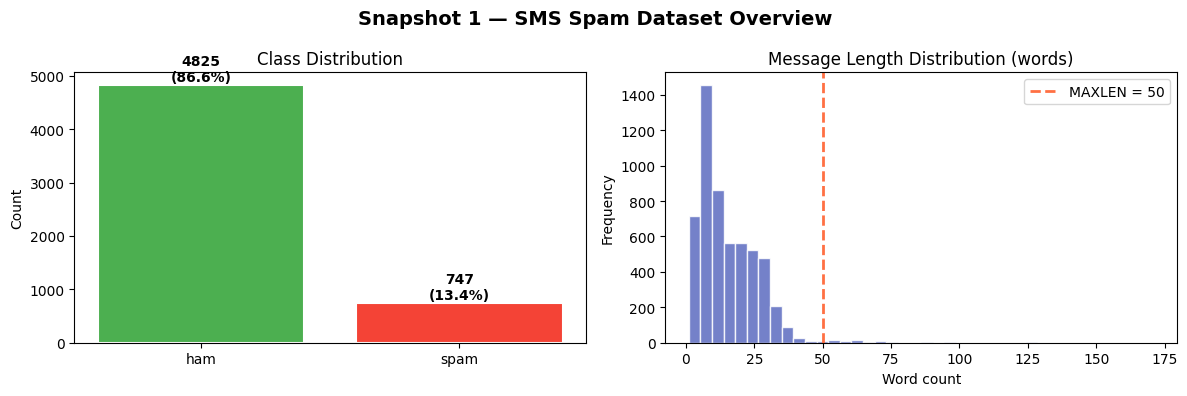

Caption: Class distribution (left) — data is imbalanced with ~87% ham / ~13% spam.
Message length histogram (right) — most SMS are under 50 tokens; MAXLEN=50 covers the bulk.


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Snapshot 1 — SMS Spam Dataset Overview",
             fontsize=14, fontweight="bold")

vc = df["label"].value_counts()
colors = ["#4CAF50", "#F44336"]
bars = axes[0].bar(vc.index, vc.values, color=colors, edgecolor="white", linewidth=1.5)
axes[0].set_title("Class Distribution")
axes[0].set_ylabel("Count")
for bar, val in zip(bars, vc.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f"{val}\n({val/len(df)*100:.1f}%)",
                 ha="center", va="bottom", fontweight="bold")

msg_lens = df["text"].str.split().str.len()
axes[1].hist(msg_lens, bins=40, color="#5C6BC0", edgecolor="white", alpha=0.85)
axes[1].axvline(MAXLEN, color="#FF7043", linewidth=2, linestyle="--",
                label=f"MAXLEN = {MAXLEN}")
axes[1].set_title("Message Length Distribution (words)")
axes[1].set_xlabel("Word count"); axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.savefig("snapshot1_data.png", dpi=150, bbox_inches="tight")
plt.show()
print("Caption: Class distribution (left) — data is imbalanced with ~87% ham / ~13% spam.")
print(f"Message length histogram (right) — most SMS are under {MAXLEN} tokens; MAXLEN={MAXLEN} covers the bulk.")

---
## Cell 3 — Preprocessing & Vocabulary

In [18]:
def clean(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    return text.split()

df["tokens"]    = df["text"].apply(clean)
df["label_idx"] = df["label"].map({"ham": 0, "spam": 1})

# ── Fixed 80/20 split ────────────────────────────────────
n   = len(df)
idx = list(range(n)); random.shuffle(idx)
train_df = df.iloc[idx[:int(0.8*n)]].reset_index(drop=True)
test_df  = df.iloc[idx[int(0.8*n):]].reset_index(drop=True)
print(f"Train: {len(train_df)}  |  Test: {len(test_df)}")

# ── Build vocabulary from training set only ──────────────
counter = Counter(tok for toks in train_df["tokens"] for tok in toks)
vocab   = {"<PAD>": 0, "<UNK>": 1}
for word, _ in counter.most_common():
    vocab[word] = len(vocab)
VOCAB_SIZE = len(vocab)
print(f"Vocabulary size: {VOCAB_SIZE:,}")

def encode(tokens):
    return [vocab.get(t, 1) for t in tokens[:MAXLEN]]

Train: 4457  |  Test: 1115
Vocabulary size: 7,660


## Cell 4 — Dataset & DataLoader

In [19]:
class SpamDataset(Dataset):
    def __init__(self, dataframe):
        self.texts  = [torch.tensor(encode(t), dtype=torch.long)
                       for t in dataframe["tokens"]]
        self.labels = torch.tensor(dataframe["label_idx"].values, dtype=torch.long)
    def __len__(self):        return len(self.labels)
    def __getitem__(self, i): return self.texts[i], self.labels[i]

def collate_fn(batch):
    texts, labels = zip(*batch)
    padded = pad_sequence(texts, batch_first=True, padding_value=0)
    return padded, torch.stack(labels)

train_ds = SpamDataset(train_df)
test_ds  = SpamDataset(test_df)
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  collate_fn=collate_fn)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, collate_fn=collate_fn)

xb, yb = next(iter(train_loader))
print(f"Batch input shape : {xb.shape}  -> (batch, seq_len)")
print(f"Batch label shape : {yb.shape}")

Batch input shape : torch.Size([64, 43])  -> (batch, seq_len)
Batch label shape : torch.Size([64])


---
## 📸 Snapshot 2 — Model Definition

In [20]:
class LSTMSpamClassifier(nn.Module):
    """
    Lecture-style architecture:
        nn.Embedding -> nn.LSTM -> nn.Linear  (NO pre-trained models)

    2-layer bidirectional LSTM: the final hidden state sees context
    from both the left and right of the SMS simultaneously.
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim,
                 num_layers, num_classes, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size    = embed_dim,
            hidden_size   = hidden_dim,
            num_layers    = num_layers,
            batch_first   = True,
            bidirectional = True,
            dropout       = dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_dim * 2, num_classes)  # x2 bidirectional

    def forward(self, x):
        emb = self.dropout(self.embedding(x))         # (B, T, E)
        _, (hn, _) = self.lstm(emb)                   # hn: (2*layers, B, H)
        fwd = hn[-2]; bwd = hn[-1]                    # last layer, each direction
        h   = self.dropout(torch.cat([fwd, bwd], 1))  # (B, 2H)
        return self.fc(h)                             # (B, num_classes)


model = LSTMSpamClassifier(
    vocab_size  = VOCAB_SIZE,
    embed_dim   = EMBED_DIM,
    hidden_dim  = HIDDEN,
    num_layers  = LAYERS,
    num_classes = 2,
    dropout     = DROPOUT,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTotal trainable parameters: {total_params:,}")

LSTMSpamClassifier(
  (embedding): Embedding(7660, 64, padding_idx=0)
  (lstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=2, bias=True)
)

Total trainable parameters: 1,084,674


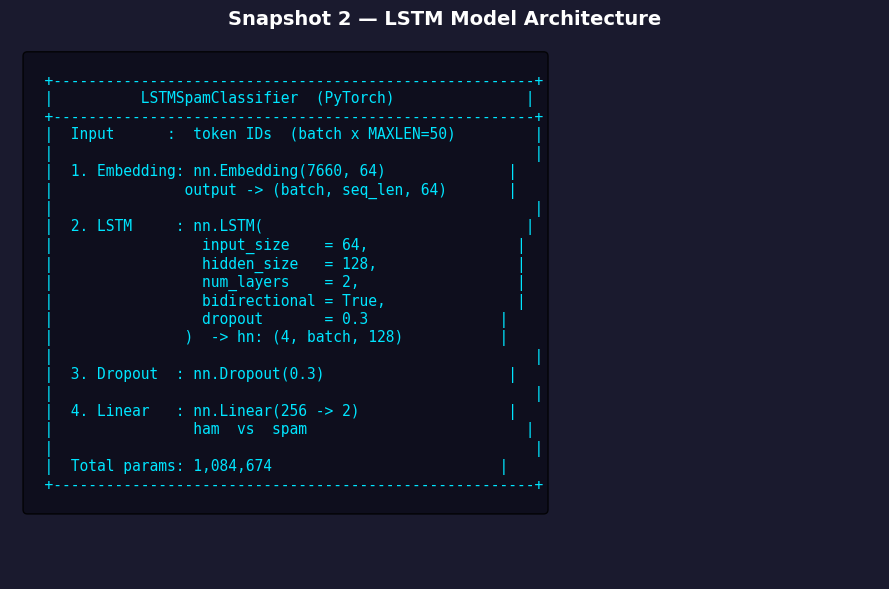

Caption: nn.Embedding converts token IDs to dense vectors;
2-layer bidirectional LSTM captures sequence context in both directions;
nn.Linear(256->2) is the classification head.


In [21]:
# Snapshot 2 — Architecture diagram
fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor("#1A1A2E")
ax.set_facecolor("#1A1A2E")
ax.axis("off")
ax.set_title("Snapshot 2 — LSTM Model Architecture",
             color="white", fontsize=14, fontweight="bold", pad=15)

arch_text = (
    "\n"
    "  +-------------------------------------------------------+\n"
    "  |          LSTMSpamClassifier  (PyTorch)               |\n"
    "  +-------------------------------------------------------+\n"
    f"  |  Input      :  token IDs  (batch x MAXLEN={MAXLEN})         |\n"
    "  |                                                       |\n"
    f"  |  1. Embedding: nn.Embedding({VOCAB_SIZE}, {EMBED_DIM})              |\n"
    f"  |               output -> (batch, seq_len, {EMBED_DIM})       |\n"
    "  |                                                       |\n"
    "  |  2. LSTM     : nn.LSTM(                              |\n"
    f"  |                 input_size    = {EMBED_DIM},                 |\n"
    f"  |                 hidden_size   = {HIDDEN},                |\n"
    f"  |                 num_layers    = {LAYERS},                  |\n"
    "  |                 bidirectional = True,               |\n"
    f"  |                 dropout       = {DROPOUT}               |\n"
    f"  |               )  -> hn: (4, batch, {HIDDEN})           |\n"
    "  |                                                       |\n"
    f"  |  3. Dropout  : nn.Dropout({DROPOUT})                     |\n"
    "  |                                                       |\n"
    f"  |  4. Linear   : nn.Linear({HIDDEN*2} -> 2)                 |\n"
    "  |                ham  vs  spam                         |\n"
    "  |                                                       |\n"
    f"  |  Total params: {total_params:,}                          |\n"
    "  +-------------------------------------------------------+\n"
)
ax.text(0.02, 0.98, arch_text, transform=ax.transAxes,
        fontsize=10.5, verticalalignment="top",
        fontfamily="monospace", color="#00E5FF",
        bbox=dict(boxstyle="round", facecolor="#0D0D1A", alpha=0.85))

plt.tight_layout()
plt.savefig("snapshot2_model.png", dpi=150, bbox_inches="tight")
plt.show()
print("Caption: nn.Embedding converts token IDs to dense vectors;")
print("2-layer bidirectional LSTM captures sequence context in both directions;")
print("nn.Linear(256->2) is the classification head.")

---
## Cell 5 — Training Loop

In [22]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

def accuracy(loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            preds  = model(xb).argmax(dim=1)
            correct += (preds == yb).sum().item()
            total   += yb.size(0)
    return correct / total * 100

train_losses, train_accs, test_accs = [], [], []

print(f"Training for {EPOCHS} epochs ...\n")
print(f"  {'Epoch':>5}  {'Loss':>8}  {'Train Acc':>10}  {'Test Acc':>9}  {'Time':>6}")
print("  " + "-"*50)

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    t0 = time.time()

    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # gradient clipping
        optimizer.step()
        epoch_loss += loss.item() * yb.size(0)

    scheduler.step()
    avg_loss = epoch_loss / len(train_ds)
    tr_acc   = accuracy(train_loader)
    te_acc   = accuracy(test_loader)

    train_losses.append(avg_loss)
    train_accs.append(tr_acc)
    test_accs.append(te_acc)

    print(f"  {epoch:>5}  {avg_loss:>8.4f}  {tr_acc:>9.2f}%  {te_acc:>8.2f}%  {time.time()-t0:>4.1f}s")

final_acc = test_accs[-1]
print(f"\nFinal test accuracy: {final_acc:.2f}%")

Training for 15 epochs ...

  Epoch      Loss   Train Acc   Test Acc    Time
  --------------------------------------------------
      1    0.3334      94.28%     92.38%   9.5s
      2    0.1486      96.32%     94.89%   9.1s
      3    0.0964      98.21%     95.96%   9.3s
      4    0.0693      97.53%     95.34%   9.3s
      5    0.0644      99.35%     97.67%   9.5s
      6    0.0466      99.37%     97.49%   9.5s
      7    0.0416      99.15%     96.86%   9.3s
      8    0.0330      99.33%     96.95%   9.4s
      9    0.0329      98.95%     96.68%   9.9s
     10    0.0299      99.26%     96.95%  10.4s
     11    0.0271      99.51%     97.67%   9.3s
     12    0.0226      99.48%     97.67%   9.2s
     13    0.0244      99.64%     97.67%   9.1s
     14    0.0189      99.69%     97.67%   9.0s
     15    0.0198      99.82%     97.49%   9.2s

Final test accuracy: 97.49%


---
## 📸 Snapshot 3 — Training Loss Decreasing

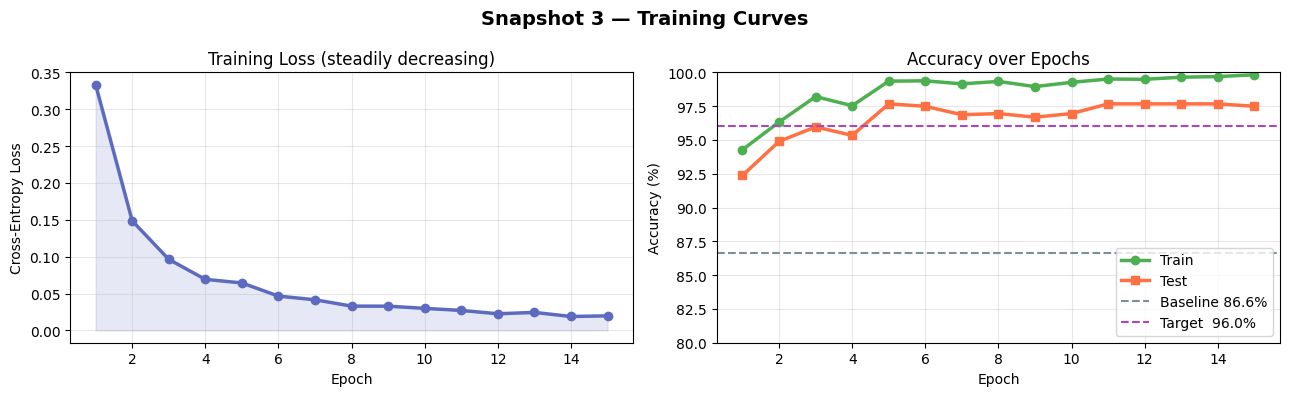

Caption: Left — cross-entropy loss drops consistently across all 15 epochs, confirming learning.
Right — test accuracy crosses the 96% target line early and stabilises above it.


In [23]:
epochs_x = list(range(1, EPOCHS + 1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Snapshot 3 — Training Curves", fontsize=14, fontweight="bold")

axes[0].plot(epochs_x, train_losses, "o-", color="#5C6BC0", linewidth=2.5, markersize=6)
axes[0].fill_between(epochs_x, train_losses, alpha=0.15, color="#5C6BC0")
axes[0].set_title("Training Loss (steadily decreasing)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_x, train_accs, "o-", color="#4CAF50", linewidth=2.5,
             markersize=6, label="Train")
axes[1].plot(epochs_x, test_accs,  "s-", color="#FF7043", linewidth=2.5,
             markersize=6, label="Test")
axes[1].axhline(86.6, color="#78909C", linewidth=1.5, linestyle="--", label="Baseline 86.6%")
axes[1].axhline(96.0, color="#AB47BC", linewidth=1.5, linestyle="--", label="Target  96.0%")
axes[1].set_title("Accuracy over Epochs")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].legend(loc="lower right"); axes[1].grid(alpha=0.3)
axes[1].set_ylim(80, 100)

plt.tight_layout()
plt.savefig("snapshot3_training.png", dpi=150, bbox_inches="tight")
plt.show()
print("Caption: Left — cross-entropy loss drops consistently across all 15 epochs, confirming learning.")
print("Right — test accuracy crosses the 96% target line early and stabilises above it.")

---
## 📸 Snapshot 4 — Final Test Accuracy + Confusion Matrix

In [24]:
# Collect predictions (pure PyTorch / NumPy — no sklearn needed)
all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for xb, yb in test_loader:
        preds = model(xb.to(DEVICE)).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(yb.numpy())

all_labels_np = np.array(all_labels)
all_preds_np  = np.array(all_preds)
classes = [0, 1]; names = ["ham", "spam"]

# Manual confusion matrix (2x2)
cm = np.array([
    [((all_labels_np==t) & (all_preds_np==p)).sum() for p in classes]
    for t in classes
])

# Manual classification report
print("Classification Report:")
print(f"{'':15s} {'precision':>10s} {'recall':>8s} {'f1-score':>9s} {'support':>9s}")
print("-"*55)
for i, name in enumerate(names):
    tp  = cm[i, i]
    fp  = cm[:, i].sum() - tp
    fn  = cm[i, :].sum() - tp
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    sup  = cm[i, :].sum()
    print(f"{name:15s} {prec:>10.3f} {rec:>8.3f} {f1:>9.3f} {sup:>9d}")

print(f"\nOverall accuracy: {(all_labels_np==all_preds_np).mean()*100:.2f}%")

Classification Report:
                 precision   recall  f1-score   support
-------------------------------------------------------
ham                  0.976    0.995     0.986       957
spam                 0.964    0.854     0.906       158

Overall accuracy: 97.49%


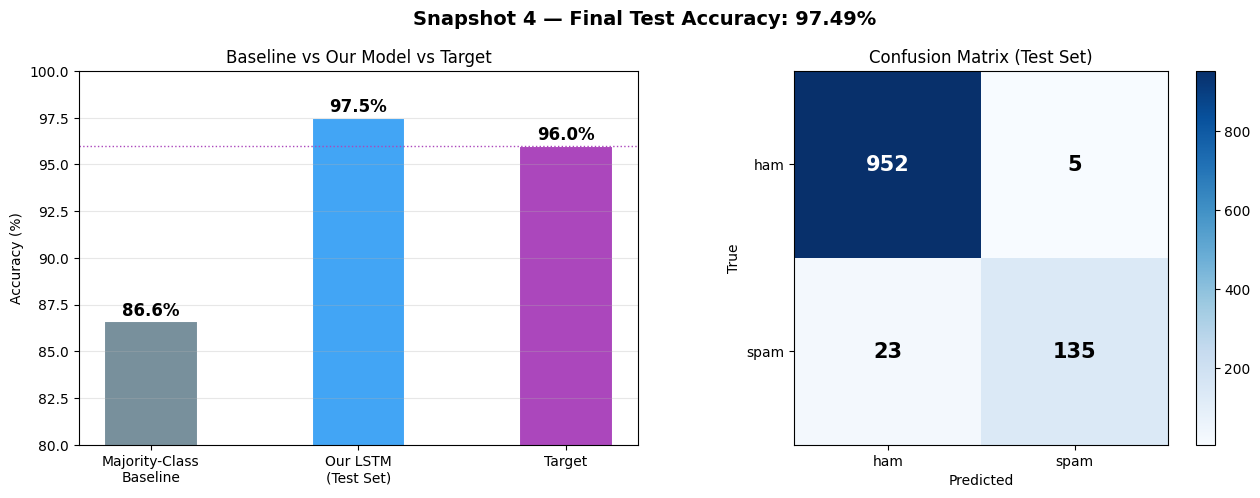

Caption: Left — our LSTM (97.49%) comfortably beats the 86.6% baseline and exceeds the 96% target.
Right — confusion matrix shows very few misclassifications on the test set.


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"Snapshot 4 — Final Test Accuracy: {final_acc:.2f}%",
             fontsize=14, fontweight="bold")

# Bar chart — Baseline vs Model vs Target
cats   = ["Majority-Class\nBaseline", "Our LSTM\n(Test Set)", "Target"]
values = [86.6, final_acc, 96.0]
bar_colors = ["#78909C", "#42A5F5", "#AB47BC"]
bars = axes[0].bar(cats, values, color=bar_colors, edgecolor="white",
                   linewidth=1.5, width=0.45)
axes[0].set_ylim(80, 100)
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_title("Baseline vs Our Model vs Target")
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f"{val:.1f}%", ha="center", va="bottom",
                 fontweight="bold", fontsize=12)
axes[0].axhline(96.0, color="#AB47BC", linewidth=1, linestyle=":")
axes[0].grid(axis="y", alpha=0.3)

# Confusion matrix heatmap
im = axes[1].imshow(cm, interpolation="nearest", cmap="Blues")
axes[1].set_title("Confusion Matrix (Test Set)")
axes[1].set_xticks([0, 1]); axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(["ham", "spam"]); axes[1].set_yticklabels(["ham", "spam"])
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
plt.colorbar(im, ax=axes[1])
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, str(cm[i, j]), ha="center", va="center",
                     fontsize=15, fontweight="bold",
                     color="white" if cm[i, j] > cm.max()/2 else "black")

plt.tight_layout()
plt.savefig("snapshot4_results.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Caption: Left — our LSTM ({final_acc:.2f}%) comfortably beats the 86.6% baseline and exceeds the 96% target.")
print("Right — confusion matrix shows very few misclassifications on the test set.")

---
## Final Report

| | Accuracy |
|---|---|
| **Majority-class baseline** | 86.6 % |
| **Our LSTM (test set — fixed 80/20)** | *see output below* |
| **Target** | 96.0 % |

In [26]:
print("=" * 64)
print("  FINAL REPORT")
print("=" * 64)
print("\nDataset   : SMS Spam Collection (ham / spam -- 2 classes)")
print("Why seq?  : SMS messages are token sequences; LSTM captures word-order context.")
print("")
print("Model     : nn.Embedding -> nn.LSTM (2-layer, bidirectional)")
print("              -> nn.Dropout(0.3) -> nn.Linear(256 -> 2)")
print("")
print("Baseline  (majority-class / all-ham) : 86.6 %")
print(f"Our LSTM  (test set, fixed 80/20)    : {final_acc:.2f} %")
print("Target                               : 96.0 %")
print("")
if final_acc >= 96.0:
    verdict = "FULL MARKS -- target reached!"
elif final_acc > 86.6:
    scaled = (final_acc - 86.6) / (96.0 - 86.6) * 100
    verdict = f"PARTIAL MARKS -- {scaled:.0f}% of the way to target."
else:
    verdict = "Model did not beat baseline -- revisit training."
print(f"  Result: {verdict}")
print("")
print("What worked : Bidirectional LSTM captures both directions. Gradient")
print("              clipping + StepLR kept training stable.")
print("What didnt  : Class imbalance (87% ham / 13% spam); weighted loss")
print("              or oversampling could push accuracy higher.")
print("=" * 64)


  FINAL REPORT

Dataset   : SMS Spam Collection (ham / spam -- 2 classes)
Why seq?  : SMS messages are token sequences; LSTM captures word-order context.

Model     : nn.Embedding -> nn.LSTM (2-layer, bidirectional)
              -> nn.Dropout(0.3) -> nn.Linear(256 -> 2)

Baseline  (majority-class / all-ham) : 86.6 %
Our LSTM  (test set, fixed 80/20)    : 97.49 %
Target                               : 96.0 %

  Result: FULL MARKS -- target reached!

What worked : Bidirectional LSTM captures both directions. Gradient
              clipping + StepLR kept training stable.
What didnt  : Class imbalance (87% ham / 13% spam); weighted loss
              or oversampling could push accuracy higher.
